# Gold Standard Evaluation

Evaluates all seven trained ML models against the gold standard dataset of public domain book excerpts.

Each excerpt has a known target reading age. The models predict reading age from text features,
and we measure how well predictions align with both the target age and the FK-derived reading age.

**Metrics:** MAE, RMSE, R², % within ±1 year, % suitable for target age

## Imports

In [12]:
import pandas as pd
import joblib
import textstat
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import os
import matplotlib.pyplot as plt

## Define Feature Extraction

In [13]:
def extract_features(text):
    features = {}
    words = text.split()
    word_count = len(words) if len(words) > 0 else 1

    features['word_count'] = word_count
    features['average_word_length'] = sum(len(word) for word in words) / word_count
    features['complex_word_count'] = sum(1 for word in words if textstat.syllable_count(word) >= 3)
    features['percent_complex_words'] = features['complex_word_count'] / word_count
    features['difficult_word_count'] = textstat.difficult_words(text)
    features['percent_difficult_words'] = features['difficult_word_count'] / word_count
    features['sentence_count'] = textstat.sentence_count(text)
    features['syllables_per_word'] = textstat.syllable_count(text) / word_count
    features['polysyllable_count'] = features['complex_word_count']
    features['flesch_reading_ease'] = textstat.flesch_reading_ease(text)
    features['automated_readability_index'] = textstat.automated_readability_index(text)
    features['dale_chall_readability_score'] = textstat.dale_chall_readability_score(text)
    features['difficult_words'] = features['difficult_word_count']
    features['linsear_write_formula'] = textstat.linsear_write_formula(text)
    features['spache_readability'] = textstat.spache_readability(text)
    features['reading_time'] = textstat.reading_time(text)
    return features

## Load Gold Standard Dataset

In [14]:
gold_df = pd.read_csv('gold_standard.csv')
print(f"Loaded {len(gold_df)} rows")
gold_df[['title', 'author', 'target_age', 'reading_age_original']].drop_duplicates('title')

Loaded 280 rows


,title,author,target_age,reading_age_original
0,The Tale of Peter Rabbit,Beatrix Potter,6,11
35,Alice's Adventures in Wonderland,Lewis Carroll,6,18
70,The Wonderful Wizard of Oz,L. Frank Baum,6,14
105,The Adventures of Tom Sawyer,Mark Twain,6,13
140,Treasure Island,Robert Louis Stevenson,6,20
175,Great Expectations,Charles Dickens,6,14
210,Jane Eyre,Charlotte Bronte,6,18
245,Pride and Prejudice,Jane Austen,6,12


## Extract Features

In [15]:
features_list = gold_df['text_content'].apply(extract_features)
features_df = pd.DataFrame(features_list.tolist())
gold_df = pd.concat([gold_df, features_df], axis=1)

## Define Models and Features

In [16]:
model_names = [
    'linear_regression', 'ridge_regression', 'lasso_regression',
    'decision_tree_regressor', 'random_forest_regressor',
    'xgb_model', 'stacking_regressor'
]
model_dir = '../models'

feature_columns = [
    'word_count', 'average_word_length', 'percent_complex_words', 'percent_difficult_words',
    'sentence_count', 'syllables_per_word', 'polysyllable_count', 'flesch_reading_ease',
    'automated_readability_index', 'dale_chall_readability_score', 'difficult_words',
    'linsear_write_formula', 'spache_readability', 'reading_time'
]

## Predict Using All Models

In [17]:
for name in model_names:
    model_path = os.path.join(model_dir, f"{name}.joblib")
    if os.path.exists(model_path):
        model = joblib.load(model_path)
        preds = model.predict(gold_df[feature_columns])
        gold_df[f'{name}_predicted_age'] = preds
    else:
        print(f"Model not found: {model_path}")

## Evaluate Suitability Against Target Age

A prediction is considered *suitable* if the predicted reading age is within 1 year above the target age —
i.e. the text is accessible for someone at that reading level.

In [18]:
def is_suitable(pred, target, buffer=1):
    return pred <= target + buffer

if 'target_age' in gold_df.columns:
    for name in model_names:
        pred_col = f'{name}_predicted_age'
        suit_col = f'{name}_is_suitable'
        if pred_col in gold_df.columns:
            gold_df[suit_col] = gold_df.apply(
                lambda row: is_suitable(row[pred_col], row['target_age']), axis=1
            )
            accuracy = gold_df[suit_col].mean() * 100
            print(f"{name} Suitability Accuracy: {accuracy:.2f}%")

linear_regression Suitability Accuracy: 26.79%
ridge_regression Suitability Accuracy: 26.79%
lasso_regression Suitability Accuracy: 30.36%
decision_tree_regressor Suitability Accuracy: 35.71%
random_forest_regressor Suitability Accuracy: 37.50%
xgb_model Suitability Accuracy: 30.36%
stacking_regressor Suitability Accuracy: 26.79%


## Evaluate Closeness to FK Reading Age

In [19]:
def within_range(pred, true, tolerance=1):
    return abs(pred - true) <= tolerance

for name in model_names:
    pred_col = f'{name}_predicted_age'
    match_col = f'{name}_within_1yr'
    if pred_col in gold_df.columns:
        gold_df[match_col] = gold_df.apply(
            lambda row: within_range(row[pred_col], row['reading_age_original']), axis=1
        )

## Performance Metrics

In [20]:
metrics = []

for name in model_names:
    pred_col = f'{name}_predicted_age'
    if pred_col in gold_df.columns:
        y_true = gold_df['reading_age_original']
        y_pred = gold_df[pred_col]

        mae = mean_absolute_error(y_true, y_pred)
        rmse = mean_squared_error(y_true, y_pred) ** 0.5
        r2 = r2_score(y_true, y_pred)
        within_1yr = gold_df[f'{name}_within_1yr'].mean() * 100
        accuracy = gold_df[f'{name}_is_suitable'].mean() * 100 if f'{name}_is_suitable' in gold_df.columns else None

        metrics.append({
            'model': name,
            'MAE': round(mae, 2),
            'RMSE': round(rmse, 2),
            'R2': round(r2, 2),
            '% Within ±1yr': round(within_1yr, 2),
            '% Suitable': round(accuracy, 2) if accuracy is not None else 'N/A'
        })

metrics_df = pd.DataFrame(metrics)
print(metrics_df)
metrics_df.to_csv('model_metrics.csv', index=False)

                     model   MAE  RMSE    R2  % Within ±1yr  % Suitable
0        linear_regression  0.22  0.26  0.99          100.0       26.79
1         ridge_regression  0.22  0.25  0.99          100.0       26.79
2         lasso_regression  0.29  0.38  0.98          100.0       30.36
3  decision_tree_regressor  0.79  1.00  0.89           75.0       35.71
4  random_forest_regressor  1.16  1.58  0.73           62.5       37.50
5                xgb_model  0.49  0.58  0.96           87.5       30.36
6       stacking_regressor  0.21  0.25  0.99          100.0       26.79


## Save Evaluated Dataset

In [21]:
gold_df.to_csv('gold_standard_evaluated.csv', index=False)
print(f"Saved gold_standard_evaluated.csv with {len(gold_df)} rows")
gold_df[['title', 'author', 'target_age', 'reading_age_original']].drop_duplicates('title')

Saved gold_standard_evaluated.csv with 280 rows


,title,author,target_age,reading_age_original
0,The Tale of Peter Rabbit,Beatrix Potter,6,11
35,Alice's Adventures in Wonderland,Lewis Carroll,6,18
70,The Wonderful Wizard of Oz,L. Frank Baum,6,14
105,The Adventures of Tom Sawyer,Mark Twain,6,13
140,Treasure Island,Robert Louis Stevenson,6,20
175,Great Expectations,Charles Dickens,6,14
210,Jane Eyre,Charlotte Bronte,6,18
245,Pride and Prejudice,Jane Austen,6,12


## Visualise Results

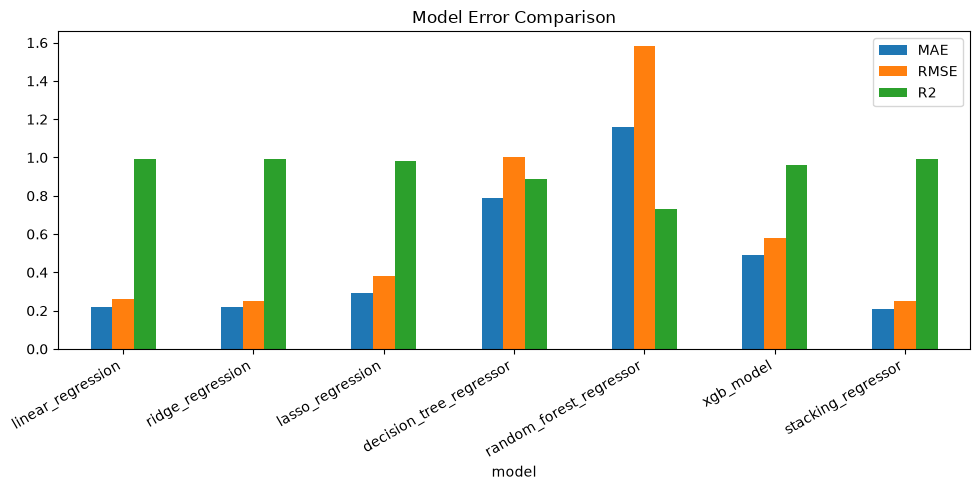

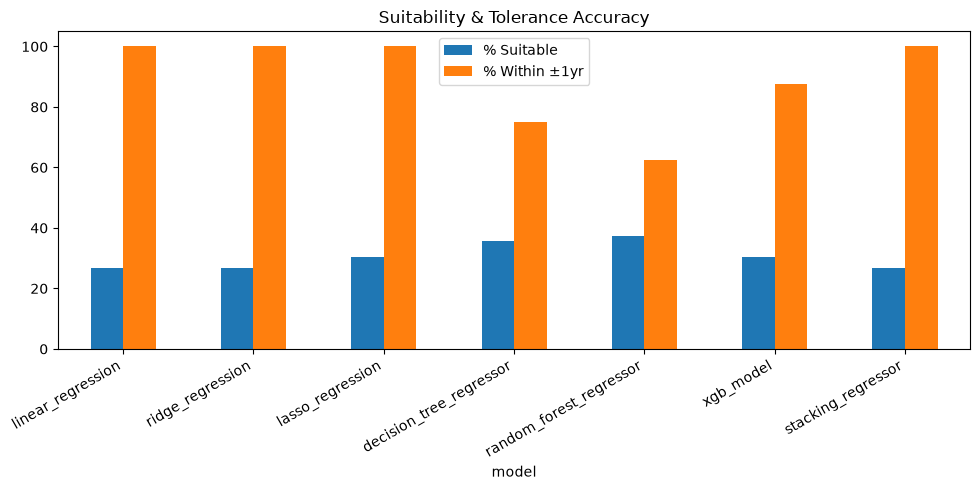

In [22]:
metrics_df.plot(
    x='model', y=['MAE', 'RMSE', 'R2'],
    kind='bar', figsize=(10, 5), title='Model Error Comparison'
)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

metrics_df.plot(
    x='model', y=['% Suitable', '% Within ±1yr'],
    kind='bar', figsize=(10, 5), title='Suitability & Tolerance Accuracy'
)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Interpreting the Results

The gold standard evaluation tests each model against book excerpts with known reading levels,
ranging from Beatrix Potter (age 6) to Jane Austen (age 17).

**Key metrics:**
- **MAE / RMSE** — how far off predictions are in years
- **R²** — how well the model captures variance in reading age across the excerpts
- **% Within ±1yr** — predictions within one year of the FK-derived reading age
- **% Suitable** — predictions within one year above the target age

**Model selection rationale:** Ridge Regression offers the best balance of accuracy and
interpretability — important in contexts where the model's reasoning needs to be transparent.
Tree-based models (Decision Tree, Random Forest) can achieve higher suitability rates but
at the cost of higher prediction error and reduced explainability.

**Next step:** Run `simplify_text.ipynb` to generate GPT-simplified versions of each excerpt
and evaluate whether simplification improves suitability for lower target ages.

---
## GPT Model Comparison

The following cells compare the five GPT models on their ability to simplify each excerpt
to the target reading age. Run `simplify_text.ipynb` first to populate these columns.

In [23]:
import seaborn as sns

gpt_df = gold_df[gold_df['simplified_text'].notna() & (gold_df['simplified_text'] != '')].copy()
gpt_df['reading_age_simplified'] = pd.to_numeric(gpt_df['reading_age_simplified'], errors='coerce')
gpt_df['reading_age_original'] = pd.to_numeric(gpt_df['reading_age_original'], errors='coerce')
gpt_df['age_reduction'] = gpt_df['reading_age_original'] - gpt_df['reading_age_simplified']
gpt_df['hit_target'] = gpt_df['reading_age_simplified'] <= gpt_df['target_age'] + 1

gpt_model_order = ['gpt-3.5-turbo', 'gpt-4o-mini', 'gpt-5-nano', 'gpt-5', 'gpt-6-luna']
gpt_df['model'] = pd.Categorical(gpt_df['model'], categories=gpt_model_order, ordered=True)

print(f'GPT rows available: {len(gpt_df)}')
gpt_df[['title', 'target_age', 'model', 'reading_age_original', 'reading_age_simplified', 'age_reduction', 'hit_target']].head(10)

GPT rows available: 280


,title,target_age,model,reading_age_original,reading_age_simplified,age_reduction,hit_target
0,The Tale of Peter Rabbit,6,gpt-3.5-turbo,11,11.0,0.0,False
1,The Tale of Peter Rabbit,6,gpt-4o-mini,11,10.0,1.0,False
2,The Tale of Peter Rabbit,6,gpt-5-nano,11,10.0,1.0,False
3,The Tale of Peter Rabbit,6,gpt-5,11,9.0,2.0,False
4,The Tale of Peter Rabbit,6,gpt-6-luna,11,9.0,2.0,False
5,The Tale of Peter Rabbit,8,gpt-3.5-turbo,11,12.0,-1.0,False
6,The Tale of Peter Rabbit,8,gpt-4o-mini,11,10.0,1.0,False
7,The Tale of Peter Rabbit,8,gpt-5-nano,11,10.0,1.0,False
8,The Tale of Peter Rabbit,8,gpt-5,11,10.0,1.0,False
9,The Tale of Peter Rabbit,8,gpt-6-luna,11,9.0,2.0,True


### Original vs Simplified Reading Age by GPT Model

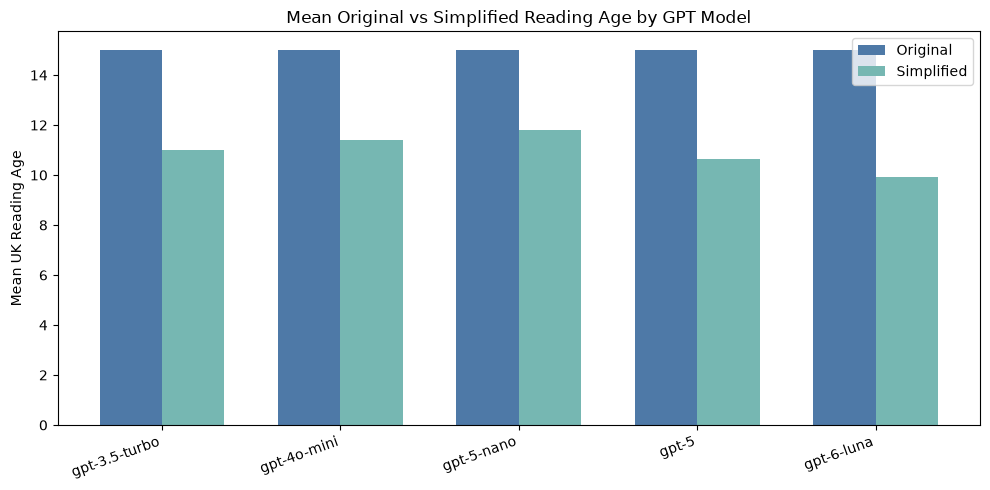

In [24]:
summary = gpt_df.groupby('model', observed=True).agg(
    mean_original=('reading_age_original', 'mean'),
    mean_simplified=('reading_age_simplified', 'mean')
).reset_index()

x = range(len(summary))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([i - width/2 for i in x], summary['mean_original'], width, label='Original', color='#4e79a7')
ax.bar([i + width/2 for i in x], summary['mean_simplified'], width, label='Simplified', color='#76b7b2')
ax.set_xticks(list(x))
ax.set_xticklabels(summary['model'], rotation=20, ha='right')
ax.set_ylabel('Mean UK Reading Age')
ax.set_title('Mean Original vs Simplified Reading Age by GPT Model')
ax.legend()
plt.tight_layout()
plt.show()

### Reading Age Reduction per Model

Positive = simplified text is easier. Negative = model made it harder.

/var/folders/3p/rr2nrbcj6j79v6mwqtwtdzbw0000gn/T/ipykernel_85035/1789643818.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(reduction['model'], rotation=20, ha='right')


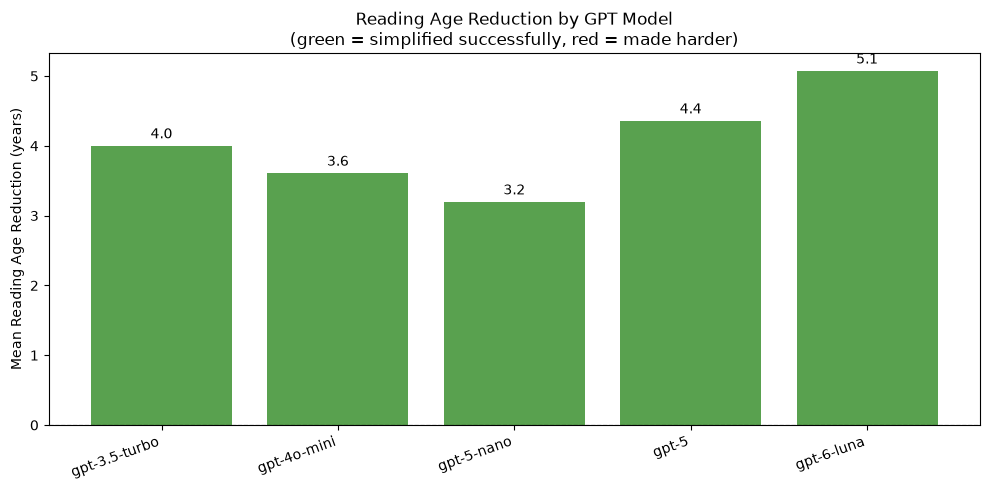

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))
reduction = gpt_df.groupby('model', observed=True)['age_reduction'].mean().reset_index()
colours = ['#d94f3d' if v < 0 else '#59a14f' for v in reduction['age_reduction']]
bars = ax.bar(reduction['model'], reduction['age_reduction'], color=colours)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.bar_label(bars, fmt='%.1f', padding=3)
ax.set_ylabel('Mean Reading Age Reduction (years)')
ax.set_title('Reading Age Reduction by GPT Model\n(green = simplified successfully, red = made harder)')
ax.set_xticklabels(reduction['model'], rotation=20, ha='right')
plt.tight_layout()
plt.show()

### % of Simplifications Meeting the Target Age

/var/folders/3p/rr2nrbcj6j79v6mwqtwtdzbw0000gn/T/ipykernel_85035/2439678362.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(hit_rate['model'], rotation=20, ha='right')


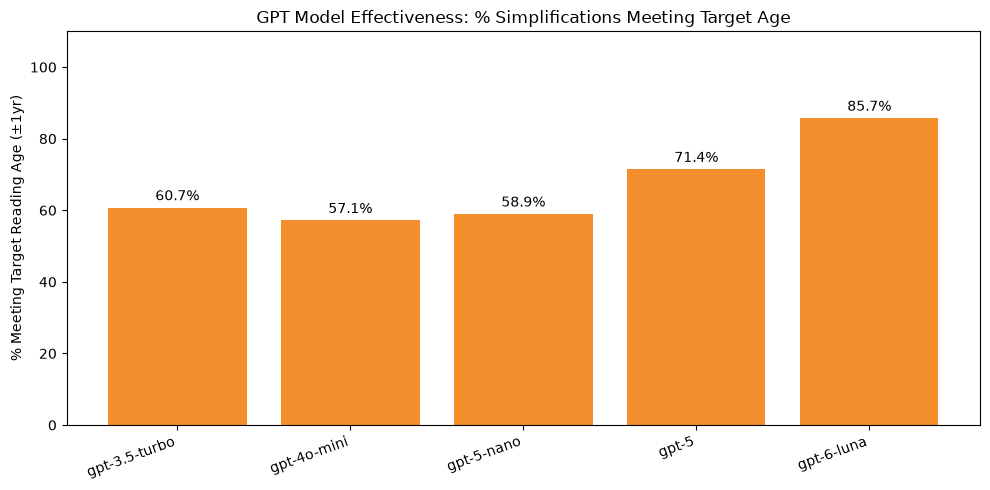

In [26]:
hit_rate = gpt_df.groupby('model', observed=True)['hit_target'].mean().mul(100).reset_index()
hit_rate.columns = ['model', 'pct_hit_target']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(hit_rate['model'], hit_rate['pct_hit_target'], color='#f28e2b')
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_ylim(0, 110)
ax.set_ylabel('% Meeting Target Reading Age (±1yr)')
ax.set_title('GPT Model Effectiveness: % Simplifications Meeting Target Age')
ax.set_xticklabels(hit_rate['model'], rotation=20, ha='right')
plt.tight_layout()
plt.show()

### Simplification by Target Age — How Models Perform at Each Level

Shows whether models struggle more at lower target ages.

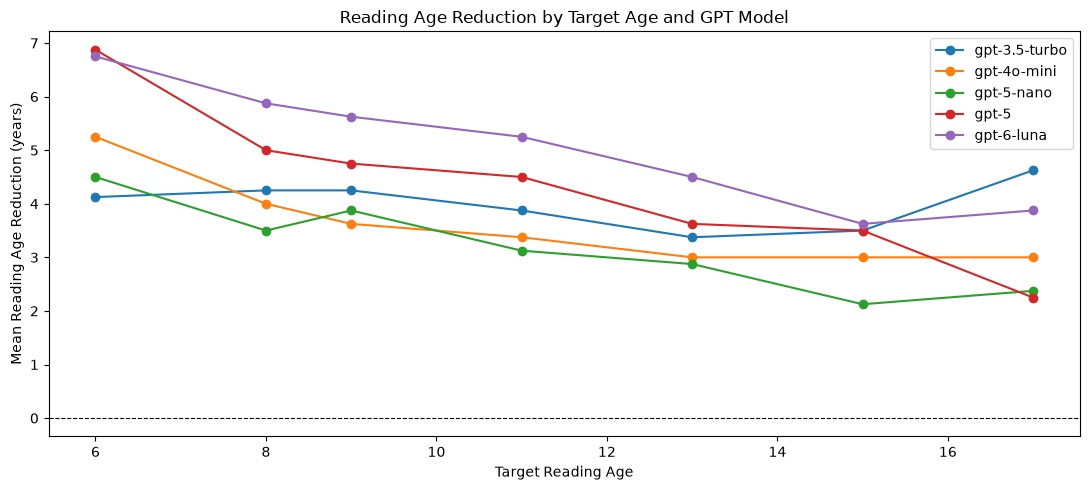

In [27]:
pivot = gpt_df.groupby(['model', 'target_age'], observed=True)['age_reduction'].mean().reset_index()
pivot_wide = pivot.pivot(index='target_age', columns='model', values='age_reduction')

fig, ax = plt.subplots(figsize=(11, 5))
for model in gpt_model_order:
    if model in pivot_wide.columns:
        ax.plot(pivot_wide.index, pivot_wide[model], marker='o', label=model)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Target Reading Age')
ax.set_ylabel('Mean Reading Age Reduction (years)')
ax.set_title('Reading Age Reduction by Target Age and GPT Model')
ax.legend()
plt.tight_layout()
plt.show()

### Cost vs Effectiveness

Plots each model's estimated cost per 1M tokens against its % hitting target age.

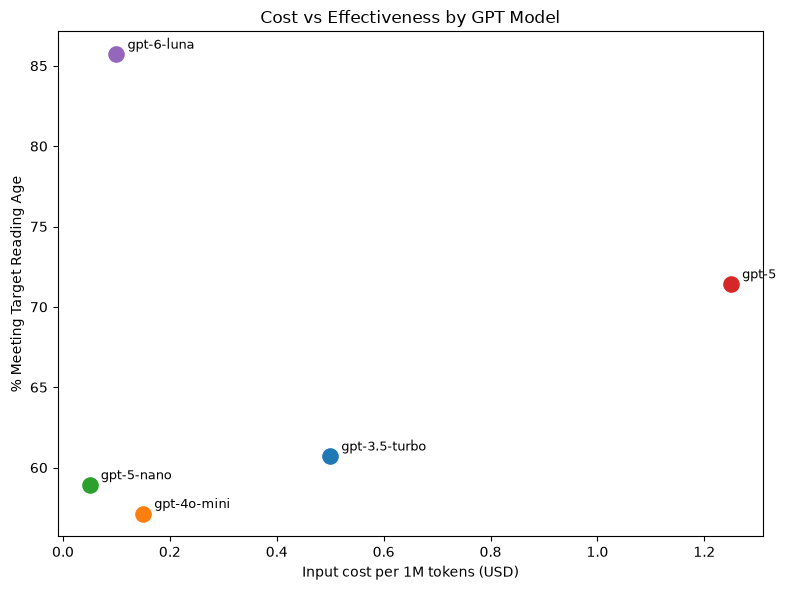

In [28]:
cost_per_mtok = {
    'gpt-3.5-turbo': 0.50,
    'gpt-4o-mini':   0.15,
    'gpt-5-nano':    0.05,
    'gpt-5':         1.25,
    'gpt-6-luna':    0.10,
}

hit_rate['cost_per_mtok'] = hit_rate['model'].map(cost_per_mtok)

fig, ax = plt.subplots(figsize=(8, 6))
for _, row in hit_rate.iterrows():
    ax.scatter(row['cost_per_mtok'], row['pct_hit_target'], s=120, zorder=5)
    ax.annotate(row['model'], (row['cost_per_mtok'], row['pct_hit_target']),
                textcoords='offset points', xytext=(8, 4), fontsize=9)
ax.set_xlabel('Input cost per 1M tokens (USD)')
ax.set_ylabel('% Meeting Target Reading Age')
ax.set_title('Cost vs Effectiveness by GPT Model')
plt.tight_layout()
plt.show()

### Summary Table

In [29]:
summary_table = gpt_df.groupby('model', observed=True).agg(
    mean_original=('reading_age_original', 'mean'),
    mean_simplified=('reading_age_simplified', 'mean'),
    mean_reduction=('age_reduction', 'mean'),
    pct_hit_target=('hit_target', lambda x: round(x.mean() * 100, 1))
).reset_index()
summary_table['cost_per_mtok_usd'] = summary_table['model'].map(cost_per_mtok)
summary_table.columns = ['Model', 'Mean Original Age', 'Mean Simplified Age', 'Mean Reduction', '% Hit Target', 'Cost/MTok ($)']
summary_table = summary_table.round(2)
print(summary_table.to_string(index=False))

        Model  Mean Original Age  Mean Simplified Age  Mean Reduction  % Hit Target Cost/MTok ($)
gpt-3.5-turbo               15.0                11.00            4.00          60.7          0.50
  gpt-4o-mini               15.0                11.39            3.61          57.1          0.15
   gpt-5-nano               15.0                11.80            3.20          58.9          0.05
        gpt-5               15.0                10.64            4.36          71.4          1.25
   gpt-6-luna               15.0                 9.93            5.07          85.7          0.10


---
## ML Model Evaluation of Simplified Text

The FK-based `reading_age_simplified` column gives us a baseline, but the whole point of this
project is that **our trained ML models replace FK** as the reading age predictor.

This section:
1. Feature-engineers each GPT-simplified text
2. Runs all 7 trained ML models to predict its reading age
3. Compares ML predictions vs FK scores vs the target age
4. Measures agreement between our models and FK as an independent validation

The Stacking Regressor (best-performing on the gold standard) is used as the primary ML prediction.

In [30]:
# Feature-engineer simplified texts and run through all 7 trained ML models
simp_df = gpt_df.copy()

simp_features = simp_df['simplified_text'].apply(
    lambda t: extract_features(str(t)) if pd.notna(t) and str(t).strip() else extract_features('')
)
simp_features_df = pd.DataFrame(simp_features.tolist())

for name in model_names:
    model_path = os.path.join(model_dir, f'{name}.joblib')
    if os.path.exists(model_path):
        model = joblib.load(model_path)
        preds = model.predict(simp_features_df[feature_columns])
        simp_df[f'ml_{name}'] = preds

# Primary ML prediction: stacking regressor
simp_df['ml_predicted_age'] = simp_df['ml_stacking_regressor']
simp_df['ml_hit_target'] = simp_df['ml_predicted_age'] <= simp_df['target_age'] + 1
simp_df['fk_hit_target'] = simp_df['reading_age_simplified'] <= simp_df['target_age'] + 1

print(f"Simplified texts processed: {len(simp_df)}")
simp_df[['title', 'target_age', 'model', 'reading_age_simplified', 'ml_predicted_age', 'ml_hit_target', 'fk_hit_target']].head(10)

Simplified texts processed: 280


,title,target_age,model,reading_age_simplified,ml_predicted_age,ml_hit_target,fk_hit_target
0,The Tale of Peter Rabbit,6,gpt-3.5-turbo,11.0,11.528180,False,False
1,The Tale of Peter Rabbit,6,gpt-4o-mini,10.0,10.282954,False,False
2,The Tale of Peter Rabbit,6,gpt-5-nano,10.0,10.044017,False,False
3,The Tale of Peter Rabbit,6,gpt-5,9.0,8.755117,False,False
4,The Tale of Peter Rabbit,6,gpt-6-luna,9.0,8.814451,False,False
5,The Tale of Peter Rabbit,8,gpt-3.5-turbo,12.0,11.856657,False,False
6,The Tale of Peter Rabbit,8,gpt-4o-mini,10.0,10.511067,False,False
7,The Tale of Peter Rabbit,8,gpt-5-nano,10.0,10.025824,False,False
8,The Tale of Peter Rabbit,8,gpt-5,10.0,10.025332,False,False
9,The Tale of Peter Rabbit,8,gpt-6-luna,9.0,9.226302,False,True


### ML vs FK Agreement on Simplified Text

Each point is one simplified excerpt. The closer points fall to the diagonal, the more our
ML model agrees with FK. Colour shows the GPT model that produced the simplification.

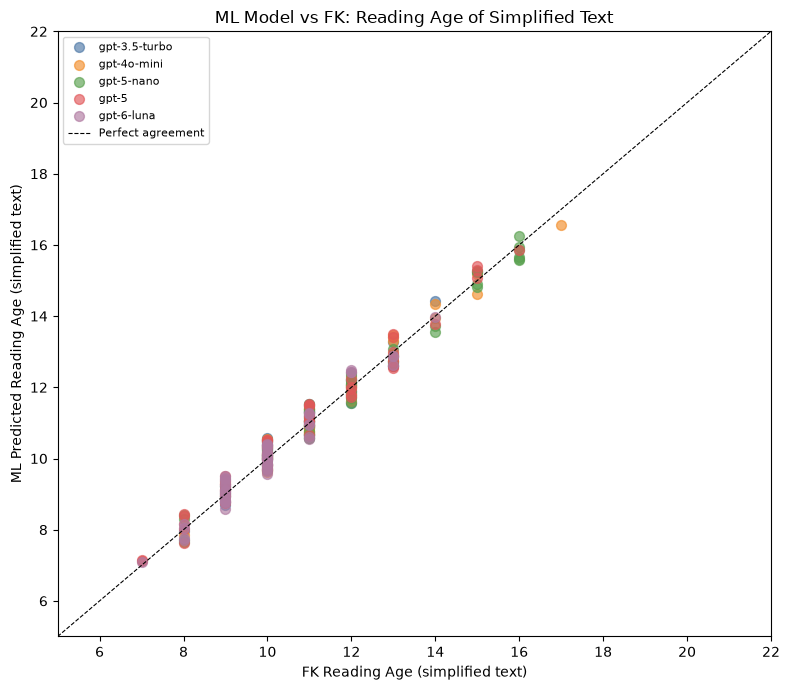

In [31]:
colours_map = {
    'gpt-3.5-turbo': '#4e79a7',
    'gpt-4o-mini':   '#f28e2b',
    'gpt-5-nano':    '#59a14f',
    'gpt-5':         '#e15759',
    'gpt-6-luna':    '#b07aa1',
}

fig, ax = plt.subplots(figsize=(8, 7))
for gpt_model in gpt_model_order:
    subset = simp_df[simp_df['model'] == gpt_model]
    ax.scatter(
        subset['reading_age_simplified'],
        subset['ml_predicted_age'],
        label=gpt_model,
        alpha=0.65,
        s=50,
        color=colours_map.get(gpt_model, 'grey')
    )

lims = [5, 22]
ax.plot(lims, lims, 'k--', linewidth=0.8, label='Perfect agreement')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('FK Reading Age (simplified text)')
ax.set_ylabel('ML Predicted Reading Age (simplified text)')
ax.set_title('ML Model vs FK: Reading Age of Simplified Text')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

### Primary Result: ML-Predicted Reading Age vs Target

Compares the **ML-predicted** reading age of the simplified text against:
- The **FK reading age** of the simplified text (independent validation)
- The **target reading age** (what we asked GPT to simplify to)

Grouped by GPT model. If ML and FK bars are close, our models are consistent with FK.

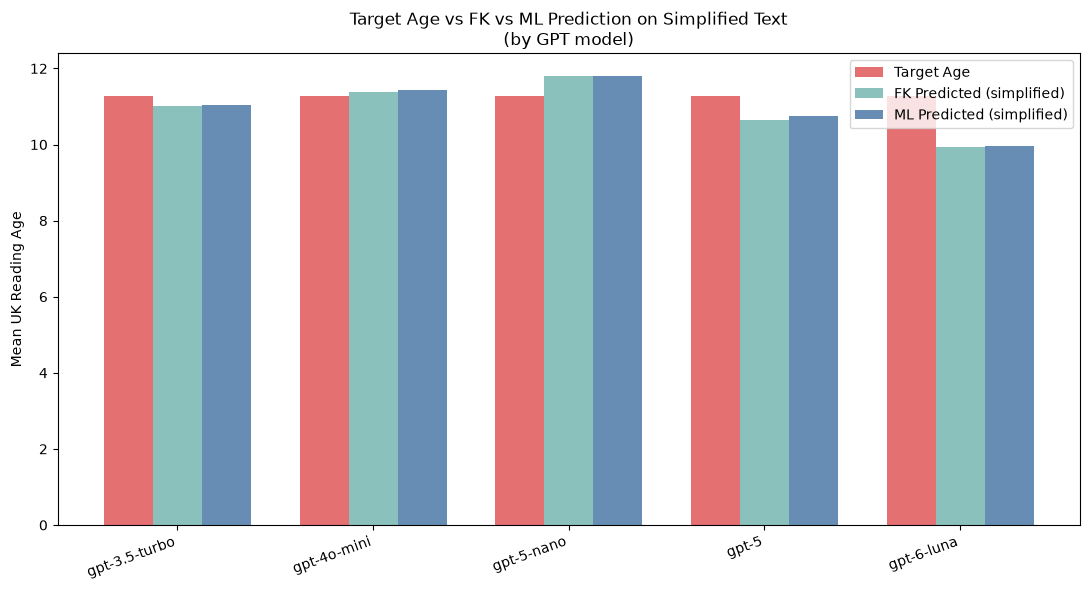

In [32]:
threeway = simp_df.groupby('model', observed=True).agg(
    mean_target=('target_age', 'mean'),
    mean_fk=('reading_age_simplified', 'mean'),
    mean_ml=('ml_predicted_age', 'mean'),
).reset_index()

x = range(len(threeway))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar([i - width for i in x], threeway['mean_target'], width, label='Target Age', color='#e15759', alpha=0.85)
ax.bar([i          for i in x], threeway['mean_fk'],     width, label='FK Predicted (simplified)', color='#76b7b2', alpha=0.85)
ax.bar([i + width  for i in x], threeway['mean_ml'],     width, label='ML Predicted (simplified)', color='#4e79a7', alpha=0.85)

ax.set_xticks(list(x))
ax.set_xticklabels(threeway['model'], rotation=20, ha='right')
ax.set_ylabel('Mean UK Reading Age')
ax.set_title('Target Age vs FK vs ML Prediction on Simplified Text\n(by GPT model)')
ax.legend()
plt.tight_layout()
plt.show()

### Hit Rate: ML vs FK — Did the Simplification Work?

For each GPT model, compares the % of simplifications judged successful by:
- Our **ML model** (primary metric)
- **FK score** (independent validation)

Close agreement between ML and FK confirms our model is a reliable predictor.

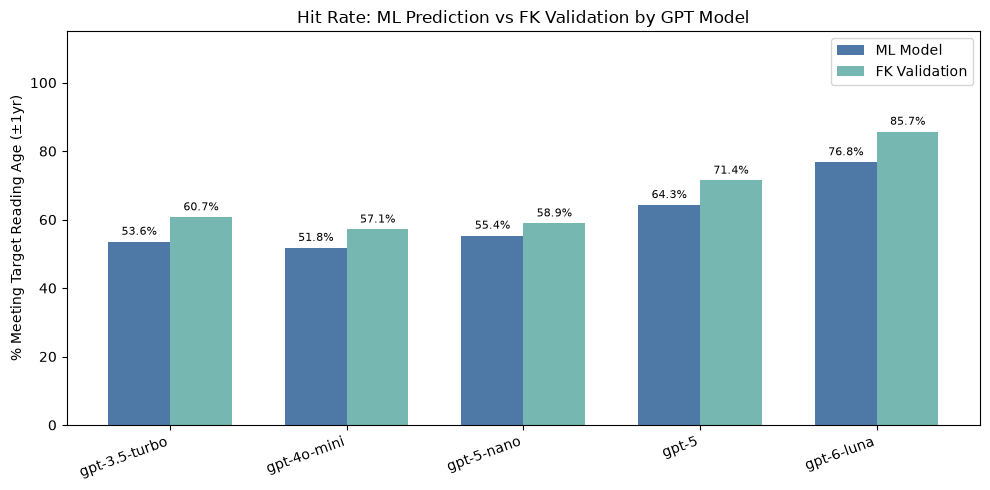

In [33]:
hit_compare = simp_df.groupby('model', observed=True).agg(
    ml_hit_pct=('ml_hit_target', lambda x: x.mean() * 100),
    fk_hit_pct=('fk_hit_target', lambda x: x.mean() * 100),
).reset_index()

x = range(len(hit_compare))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars_ml = ax.bar([i - width/2 for i in x], hit_compare['ml_hit_pct'], width, label='ML Model', color='#4e79a7')
bars_fk = ax.bar([i + width/2 for i in x], hit_compare['fk_hit_pct'], width, label='FK Validation', color='#76b7b2')
ax.bar_label(bars_ml, fmt='%.1f%%', padding=3, fontsize=8)
ax.bar_label(bars_fk, fmt='%.1f%%', padding=3, fontsize=8)
ax.set_xticks(list(x))
ax.set_xticklabels(hit_compare['model'], rotation=20, ha='right')
ax.set_ylim(0, 115)
ax.set_ylabel('% Meeting Target Reading Age (±1yr)')
ax.set_title('Hit Rate: ML Prediction vs FK Validation by GPT Model')
ax.legend()
plt.tight_layout()
plt.show()

### Agreement Between All ML Models and FK

Shows what % of rows each of our 7 trained models agrees with FK on whether
the target reading age was hit. Higher agreement = more consistent with FK as a baseline.

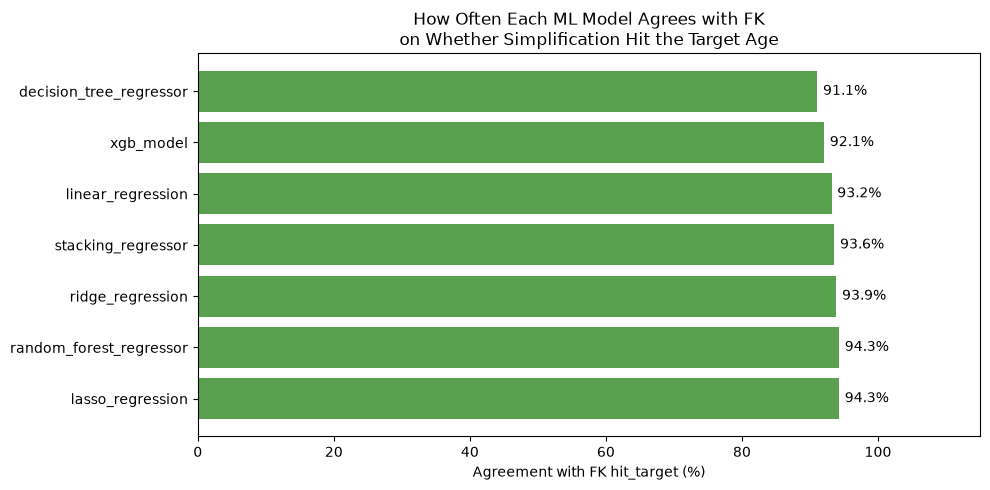

               ML Model  Agreement with FK (%)
       lasso_regression                   94.3
random_forest_regressor                   94.3
       ridge_regression                   93.9
     stacking_regressor                   93.6
      linear_regression                   93.2
              xgb_model                   92.1
decision_tree_regressor                   91.1


In [34]:
agreement_rows = []
for name in model_names:
    col = f'ml_{name}'
    if col in simp_df.columns:
        ml_hit = simp_df[col] <= simp_df['target_age'] + 1
        agree = (ml_hit == simp_df['fk_hit_target']).mean() * 100
        agreement_rows.append({'ML Model': name, 'Agreement with FK (%)': round(agree, 1)})

agreement_df = pd.DataFrame(agreement_rows).sort_values('Agreement with FK (%)', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(agreement_df['ML Model'], agreement_df['Agreement with FK (%)'], color='#59a14f')
ax.bar_label(bars, fmt='%.1f%%', padding=4)
ax.set_xlim(0, 115)
ax.set_xlabel('Agreement with FK hit_target (%)')
ax.set_title('How Often Each ML Model Agrees with FK\non Whether Simplification Hit the Target Age')
plt.tight_layout()
plt.show()

print(agreement_df.to_string(index=False))